# Laboratorio: Incertidumbre  
## Análisis Exploratorio y Preprocesamiento de Datos para Clasificación Spam/Ham

**Objetivo del notebook:** preparar, explorar y transformar el dataset `spam_ham.csv` para entender mejor las diferencias entre mensajes **spam** y **ham** antes de construir un clasificador automático.

Este notebook sigue una estructura profesional:

1. Introducción teórica.
2. Carga y validación inicial de datos.
3. Análisis exploratorio antes del preprocesamiento.
4. Preprocesamiento de texto con NLTK.
5. Análisis posterior al preprocesamiento.
6. Reflexión final y hallazgos.

## 1. Introducción teórica

En clasificación de mensajes, se suele llamar **spam** a los mensajes no deseados, promocionales, engañosos o masivos. Normalmente buscan que el usuario haga clic en un enlace, reclame un premio, responda a un número o realice alguna acción comercial.

Por otro lado, los mensajes **ham** son mensajes legítimos. En este contexto, son SMS normales enviados entre personas, como conversaciones cotidianas, recordatorios, planes o respuestas personales.

Diferenciar entre spam y ham es relevante porque permite proteger al usuario de fraudes, filtrar automáticamente contenido no deseado, reducir ruido en bandejas de entrada y mejorar sistemas de seguridad, atención al cliente o mensajería.

La clasificación automática puede aplicarse entrenando modelos de machine learning sobre características extraídas del texto. Antes de entrenar cualquier modelo, es necesario entender los datos y limpiarlos correctamente. Por eso este laboratorio se enfoca en **EDA** y **preprocesamiento de lenguaje natural**.

In [2]:
# ============================================================
# 2. Configuración inicial
# ============================================================

import os
import re
import string
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# NLTK para procesamiento de lenguaje natural
import nltk
from nltk.tokenize import wordpunct_tokenize
from nltk.stem import PorterStemmer

# WordCloud para visualización de palabras clave
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("WordCloud no está instalado. Puedes instalarlo con: pip install wordcloud")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

WordCloud no está instalado. Puedes instalarlo con: pip install wordcloud


### Nota técnica sobre el archivo

Al revisar el archivo se encontró que:

- el separador del CSV es `;`;
- la codificación compatible es `latin-1`;
- existen algunas etiquetas con comillas extra, por ejemplo `ham"""`;
- hay pocos mensajes vacíos o mal formados.

Por eso la carga se hace de forma defensiva para evitar errores de lectura.

In [3]:
# ============================================================
# 3. Carga del dataset
# ============================================================

possible_paths = [
    "spam_ham.csv",
    "/mnt/data/spam_ham.csv"
]

csv_path = None
for path in possible_paths:
    if os.path.exists(path):
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError(
        "No se encontró spam_ham.csv. Coloca el archivo en la misma carpeta del notebook."
    )

df = pd.read_csv(csv_path, sep=";", encoding="latin-1")

print("Dimensiones originales:", df.shape)
df.head()

Dimensiones originales: (5565, 2)


,Label,SMS_TEXT
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# Normalizamos nombres de columnas para trabajar de forma más clara
df = df.rename(columns={
    "Label": "label",
    "SMS_TEXT": "message"
})

# Limpieza defensiva de etiquetas y mensajes
df["label"] = (
    df["label"]
    .astype(str)
    .str.replace('"', "", regex=False)
    .str.strip()
    .str.lower()
)

df["message"] = df["message"].fillna("").astype(str)

# Nos quedamos únicamente con clases válidas
df = df[df["label"].isin(["spam", "ham"])].copy()

print("Dimensiones después de limpieza básica:", df.shape)
print("\nDistribución de clases:")
print(df["label"].value_counts())

df.head()

Dimensiones después de limpieza básica: (5565, 2)

Distribución de clases:
label
ham     4819
spam     746
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Carga y exploración inicial de datos

Primero se muestran 5 mensajes aleatorios para inspeccionar cómo vienen redactados los SMS. Esta revisión ayuda a detectar patrones como abreviaciones, números telefónicos, símbolos, enlaces, mayúsculas o palabras promocionales.

In [5]:
# 5 mensajes aleatorios
df.sample(5, random_state=42)

,label,message
626,ham,Yup i thk they r e teacher said that will make...
4743,spam,Your weekly Cool-Mob tones are ready to downlo...
3047,ham,Die... Now i have e toot fringe again...
3199,ham,Just curious because my cuz asked what I was u...
4037,ham,Hope you are not scared!


In [6]:
# Variables auxiliares antes del preprocesamiento
df["raw_length_chars"] = df["message"].str.len()
df["raw_word_count"] = df["message"].str.split().str.len()

total_messages = len(df)
class_counts = df["label"].value_counts()
class_props = df["label"].value_counts(normalize=True) * 100

print(f"Cantidad total de mensajes: {total_messages}")
print("\nCantidad por clase:")
print(class_counts)
print("\nProporción por clase (%):")
print(class_props.round(2))

Cantidad total de mensajes: 5565

Cantidad por clase:
label
ham     4819
spam     746
Name: count, dtype: int64

Proporción por clase (%):
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


### Cantidad total de mensajes

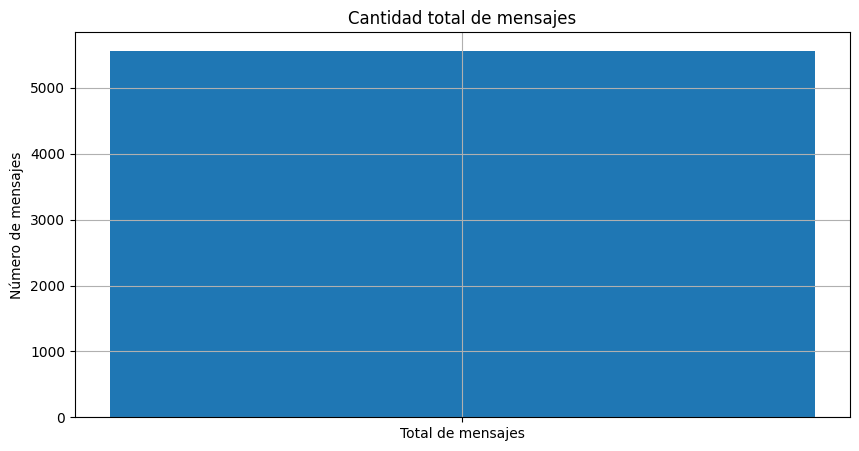

In [7]:
plt.figure()
plt.bar(["Total de mensajes"], [total_messages])
plt.title("Cantidad total de mensajes")
plt.ylabel("Número de mensajes")
plt.show()

### Distribución y proporción de spam vs ham

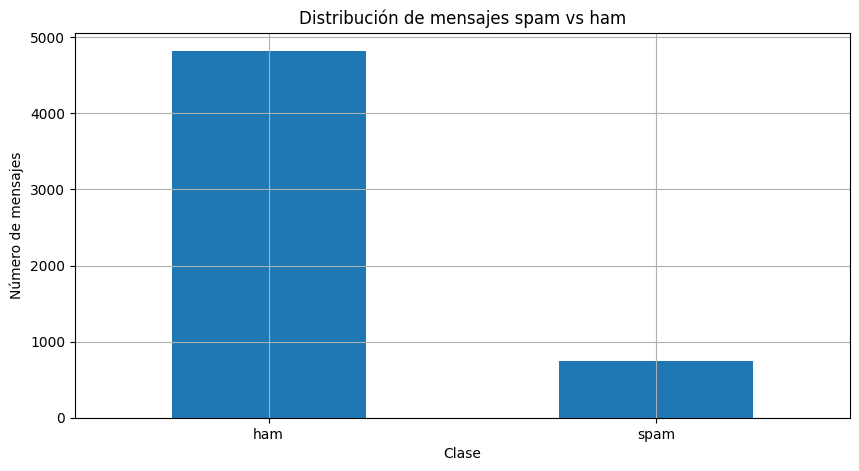

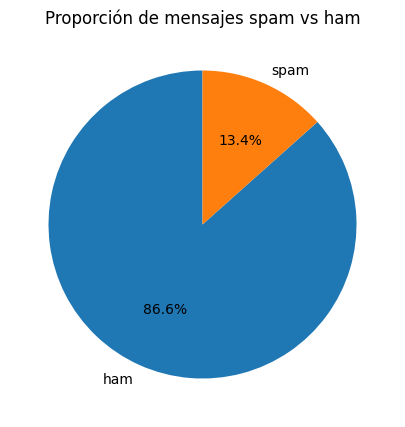

In [8]:
plt.figure()
class_counts.plot(kind="bar")
plt.title("Distribución de mensajes spam vs ham")
plt.xlabel("Clase")
plt.ylabel("Número de mensajes")
plt.xticks(rotation=0)
plt.show()

plt.figure()
class_props.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Proporción de mensajes spam vs ham")
plt.ylabel("")
plt.show()

### Densidad de longitud de mensajes spam

La longitud se mide en cantidad de caracteres. Esta variable puede ser útil porque los mensajes spam suelen contener más instrucciones, premios, enlaces, códigos o números telefónicos.

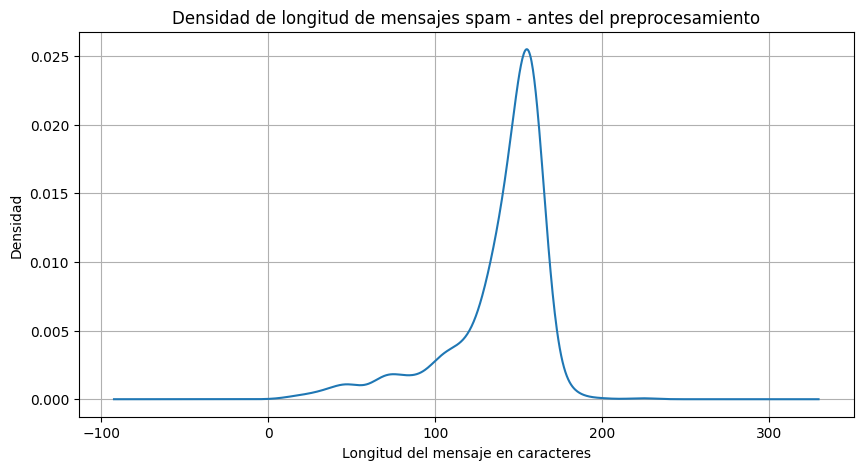

In [9]:
spam_raw_lengths = df.loc[df["label"] == "spam", "raw_length_chars"]

plt.figure()
spam_raw_lengths.plot(kind="kde")
plt.title("Densidad de longitud de mensajes spam - antes del preprocesamiento")
plt.xlabel("Longitud del mensaje en caracteres")
plt.ylabel("Densidad")
plt.show()

### Densidad de longitud de mensajes ham

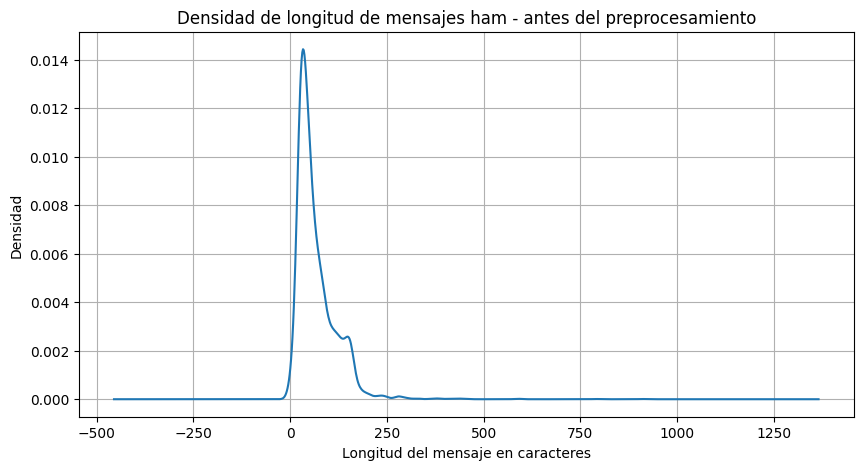

In [10]:
ham_raw_lengths = df.loc[df["label"] == "ham", "raw_length_chars"]

plt.figure()
ham_raw_lengths.plot(kind="kde")
plt.title("Densidad de longitud de mensajes ham - antes del preprocesamiento")
plt.xlabel("Longitud del mensaje en caracteres")
plt.ylabel("Densidad")
plt.show()

### Funciones auxiliares para frecuencias y WordCloud

Para el conteo inicial se tokeniza de forma simple, convirtiendo a minúsculas y conservando solamente tokens alfabéticos. En esta primera etapa todavía **no** se eliminan stopwords ni se aplica stemming; el objetivo es observar el texto casi como viene originalmente.

In [11]:
def basic_tokenize(text):
    # Tokenización básica para análisis antes del preprocesamiento.
    tokens = wordpunct_tokenize(str(text).lower())
    tokens = [token for token in tokens if token.isalpha()]
    return tokens


def get_top_words(dataframe, label, token_column, top_n=20):
    # Devuelve las top_n palabras más frecuentes para una clase.
    counter = Counter()
    for tokens in dataframe.loc[dataframe["label"] == label, token_column]:
        counter.update(tokens)
    return pd.DataFrame(counter.most_common(top_n), columns=["word", "frequency"])


def plot_top_words(top_words_df, title):
    # Grafica barras horizontales para palabras frecuentes.
    plt.figure(figsize=(10, 6))
    data = top_words_df.sort_values("frequency", ascending=True)
    plt.barh(data["word"], data["frequency"])
    plt.title(title)
    plt.xlabel("Frecuencia")
    plt.ylabel("Palabra")
    plt.show()


def plot_wordcloud(text, title):
    # Genera WordCloud si la librería está disponible.
    if not WORDCLOUD_AVAILABLE:
        print("WordCloud no disponible. Instala con: pip install wordcloud")
        return

    if not text.strip():
        print("No hay texto suficiente para generar WordCloud.")
        return

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        collocations=False
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

### Top 20 palabras más frecuentes en mensajes spam

In [12]:
df["raw_tokens"] = df["message"].apply(basic_tokenize)

top_spam_raw = get_top_words(df, "spam", "raw_tokens", top_n=20)
top_spam_raw

,word,frequency
0,to,688
1,a,377
2,call,353
3,å,299
4,you,297
5,your,264
6,free,224
7,the,206
8,for,203
9,now,198


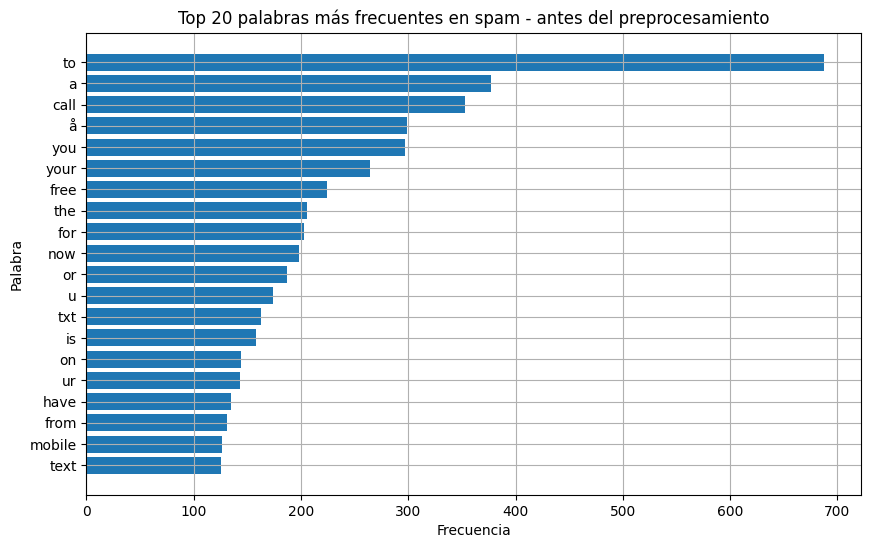

In [13]:
plot_top_words(top_spam_raw, "Top 20 palabras más frecuentes en spam - antes del preprocesamiento")

### Top 20 palabras más frecuentes en mensajes ham

In [14]:
top_ham_raw = get_top_words(df, "ham", "raw_tokens", top_n=20)
top_ham_raw

,word,frequency
0,i,2830
1,you,1871
2,to,1475
3,the,1071
4,a,1023
5,u,958
6,and,823
7,in,787
8,me,747
9,my,723


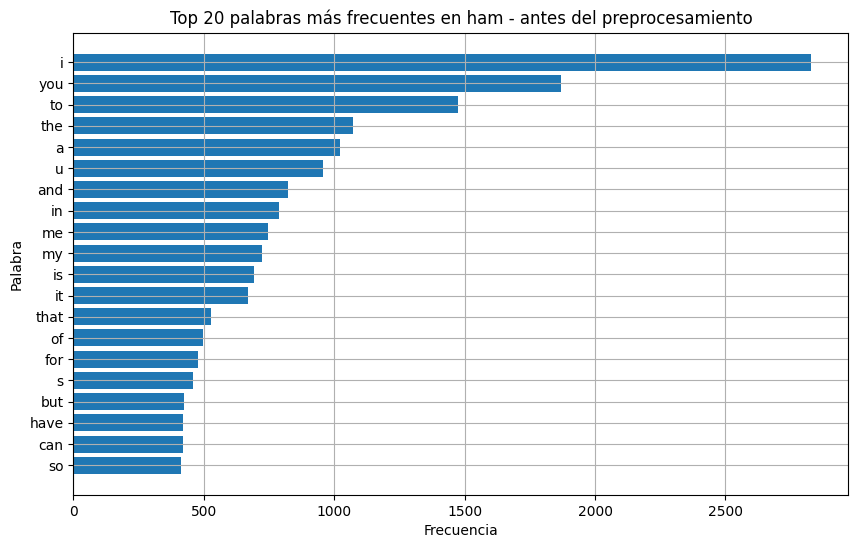

In [15]:
plot_top_words(top_ham_raw, "Top 20 palabras más frecuentes en ham - antes del preprocesamiento")

### WordCloud para mensajes spam antes del preprocesamiento

In [16]:
spam_raw_text = " ".join(df.loc[df["label"] == "spam", "message"])
plot_wordcloud(spam_raw_text, "WordCloud spam - antes del preprocesamiento")

WordCloud no disponible. Instala con: pip install wordcloud


### WordCloud para mensajes ham antes del preprocesamiento

In [17]:
ham_raw_text = " ".join(df.loc[df["label"] == "ham", "message"])
plot_wordcloud(ham_raw_text, "WordCloud ham - antes del preprocesamiento")

WordCloud no disponible. Instala con: pip install wordcloud


## 3. Preprocesamiento de texto con NLTK

El preprocesamiento transforma el texto para reducir ruido y facilitar el análisis automático. En este laboratorio se aplican las siguientes técnicas:

### 3.1 Tokenización
Consiste en dividir el texto en unidades pequeñas llamadas tokens. Usualmente los tokens son palabras, aunque también pueden ser signos, números o símbolos. Aquí se utiliza `wordpunct_tokenize` de NLTK porque es práctico para mensajes SMS con puntuación, abreviaciones y símbolos.

### 3.2 Conversión a minúsculas
Convierte todo el texto a minúsculas para que palabras como `FREE`, `Free` y `free` se traten como la misma palabra.

### 3.3 Eliminación de signos de puntuación
Se eliminan tokens que no son alfabéticos. Esto reduce ruido como puntos, comas, signos de exclamación o símbolos.

### 3.4 Eliminación de stopwords
Las stopwords son palabras muy frecuentes que normalmente aportan poco significado para distinguir clases, por ejemplo `the`, `and`, `is`, `to`. Se intentan cargar desde NLTK. Si el entorno no tiene los recursos descargados, se usa una lista de respaldo para que el notebook siga siendo ejecutable.

### 3.5 Stemming
Se eligió **stemming** con `PorterStemmer` de NLTK. El stemming reduce palabras a una raíz aproximada. Por ejemplo, `calling`, `called` y `calls` pueden reducirse a una forma común como `call`.

Se eligió stemming en lugar de lemmatization porque no depende de recursos externos como WordNet, es rápido, funciona bien como primera aproximación en textos cortos tipo SMS y ayuda a agrupar variaciones de una misma palabra.

In [18]:
# ============================================================
# 4. Preprocesamiento
# ============================================================

# Intentamos usar stopwords de NLTK.
# Si no están descargadas, el notebook usa una lista de respaldo.
try:
    from nltk.corpus import stopwords
    STOPWORDS = set(stopwords.words("english"))
    print("Stopwords cargadas desde NLTK.")
except LookupError:
    print("No se encontraron stopwords de NLTK. Intentando descargarlas...")
    try:
        nltk.download("stopwords")
        from nltk.corpus import stopwords
        STOPWORDS = set(stopwords.words("english"))
        print("Stopwords descargadas y cargadas desde NLTK.")
    except Exception:
        print("No fue posible descargar stopwords. Se usará una lista de respaldo.")
        STOPWORDS = set("""
        a about above after again against all am an and any are as at be because been before being below
        between both but by can did do does doing down during each few for from further had has have having
        he her here hers herself him himself his how i if in into is it its itself just me more most my myself
        no nor not now of off on once only or other our ours ourselves out over own same she should so some such
        than that the their theirs them themselves then there these they this those through to too under until up
        very was we were what when where which while who whom why will with you your yours yourself yourselves
        """.split())

stemmer = PorterStemmer()


def preprocess_text(text):
    # 1. minúsculas
    text = str(text).lower()

    # 2. tokenización
    tokens = wordpunct_tokenize(text)

    # 3. eliminación de puntuación y tokens no alfabéticos
    tokens = [token for token in tokens if token.isalpha()]

    # 4. eliminación de stopwords
    tokens = [token for token in tokens if token not in STOPWORDS]

    # 5. stemming
    tokens = [stemmer.stem(token) for token in tokens]

    return tokens


df["clean_tokens"] = df["message"].apply(preprocess_text)
df["clean_message"] = df["clean_tokens"].apply(lambda tokens: " ".join(tokens))

df[["label", "message", "clean_tokens", "clean_message"]].head()

No se encontraron stopwords de NLTK. Intentando descargarlas...


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alambre1\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Stopwords descargadas y cargadas desde NLTK.


,label,message,clean_tokens,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...","[go, jurong, point, crazi, avail, bugi, n, gre...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,"[ok, lar, joke, wif, u, oni]",ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entri, wkli, comp, win, fa, cup, final,...",free entri wkli comp win fa cup final tkt may ...
3,ham,U dun say so early hor... U c already then say...,"[u, dun, say, earli, hor, u, c, alreadi, say]",u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...","[nah, think, goe, usf, live, around, though]",nah think goe usf live around though


In [19]:
# Variables auxiliares posteriores al preprocesamiento
df["clean_length_chars"] = df["clean_message"].str.len()
df["clean_word_count"] = df["clean_tokens"].str.len()

summary_lengths = df.groupby("label")[
    ["raw_length_chars", "raw_word_count", "clean_length_chars", "clean_word_count"]
].mean().round(2)

summary_lengths

,raw_length_chars,raw_word_count,clean_length_chars,clean_word_count
label,,,,
ham,66.89,13.51,37.65,7.42
spam,138.73,23.84,76.76,14.32


## 4. Análisis posterior al preprocesamiento

Ahora se repiten los análisis principales usando el texto transformado. Esto permite comparar qué tanto cambian las frecuencias y longitudes cuando se elimina ruido textual.

### Cantidad total de mensajes después del preprocesamiento

El número de mensajes no debería cambiar, porque el preprocesamiento modifica el contenido textual, pero no elimina registros.

In [20]:
print(f"Cantidad total de mensajes después del preprocesamiento: {len(df)}")

Cantidad total de mensajes después del preprocesamiento: 5565


### Proporción de spam vs ham después del preprocesamiento

La proporción tampoco debería cambiar, porque las clases originales se conservan.

Cantidad por clase:
label
ham     4819
spam     746
Name: count, dtype: int64

Proporción por clase (%):
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


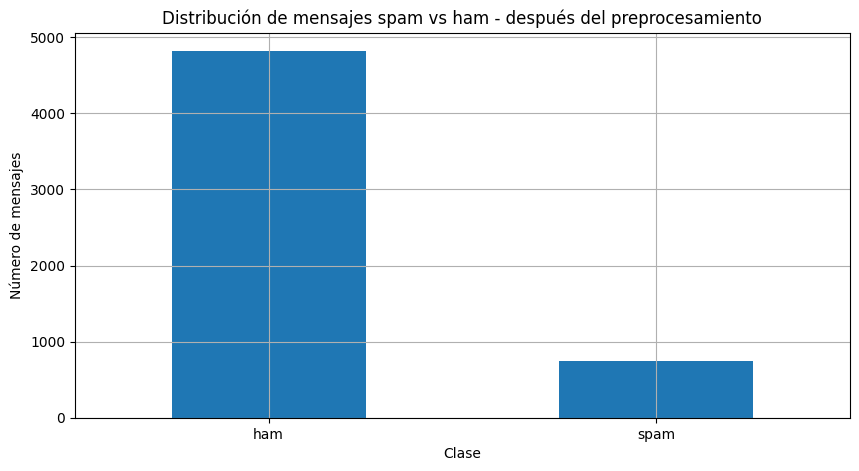

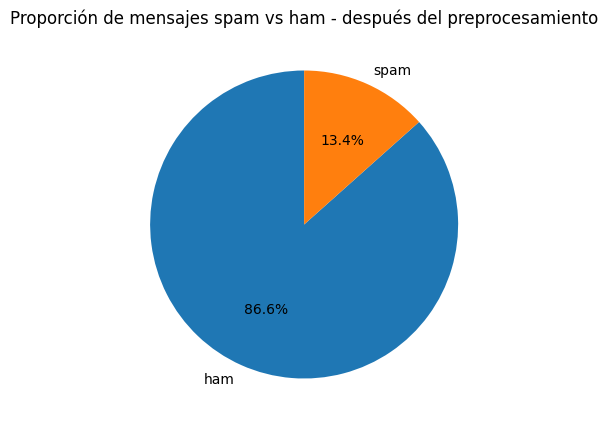

In [21]:
clean_class_counts = df["label"].value_counts()
clean_class_props = df["label"].value_counts(normalize=True) * 100

print("Cantidad por clase:")
print(clean_class_counts)
print("\nProporción por clase (%):")
print(clean_class_props.round(2))

plt.figure()
clean_class_counts.plot(kind="bar")
plt.title("Distribución de mensajes spam vs ham - después del preprocesamiento")
plt.xlabel("Clase")
plt.ylabel("Número de mensajes")
plt.xticks(rotation=0)
plt.show()

plt.figure()
clean_class_props.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Proporción de mensajes spam vs ham - después del preprocesamiento")
plt.ylabel("")
plt.show()

### Densidad de longitud de mensajes spam después del preprocesamiento

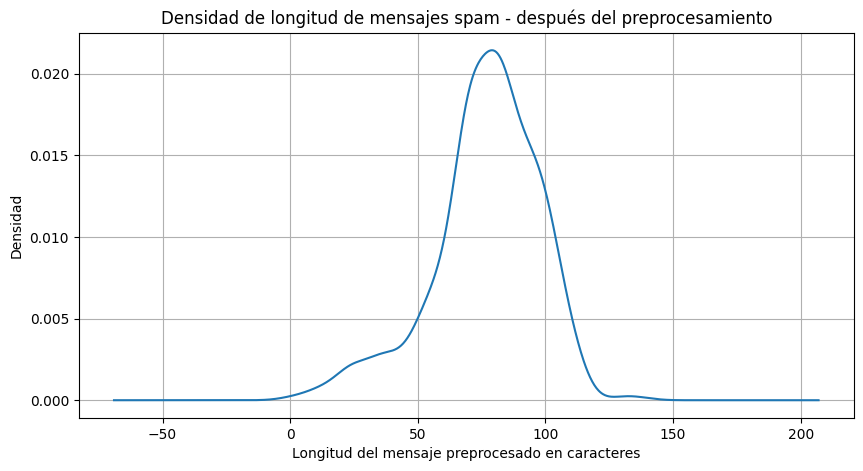

In [22]:
spam_clean_lengths = df.loc[df["label"] == "spam", "clean_length_chars"]

plt.figure()
spam_clean_lengths.plot(kind="kde")
plt.title("Densidad de longitud de mensajes spam - después del preprocesamiento")
plt.xlabel("Longitud del mensaje preprocesado en caracteres")
plt.ylabel("Densidad")
plt.show()

### Densidad de longitud de mensajes ham después del preprocesamiento

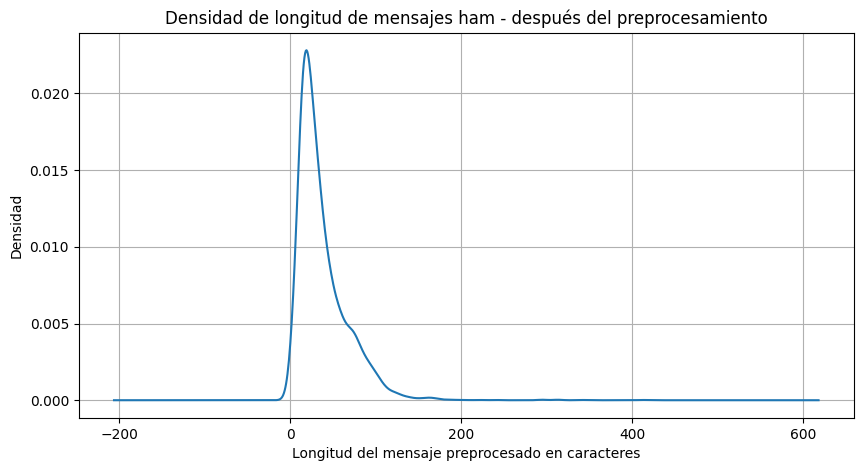

In [23]:
ham_clean_lengths = df.loc[df["label"] == "ham", "clean_length_chars"]

plt.figure()
ham_clean_lengths.plot(kind="kde")
plt.title("Densidad de longitud de mensajes ham - después del preprocesamiento")
plt.xlabel("Longitud del mensaje preprocesado en caracteres")
plt.ylabel("Densidad")
plt.show()

### Comparación de longitudes antes y después

Esta tabla permite ver si spam y ham conservan diferencias en longitud aun después de limpiar el texto.

In [24]:
summary_lengths

,raw_length_chars,raw_word_count,clean_length_chars,clean_word_count
label,,,,
ham,66.89,13.51,37.65,7.42
spam,138.73,23.84,76.76,14.32


### Top 20 palabras más frecuentes en spam después del preprocesamiento

In [25]:
top_spam_clean = get_top_words(df, "spam", "clean_tokens", top_n=20)
top_spam_clean

,word,frequency
0,call,372
1,å,299
2,free,224
3,txt,176
4,u,174
5,text,145
6,ur,143
7,mobil,138
8,stop,121
9,claim,115


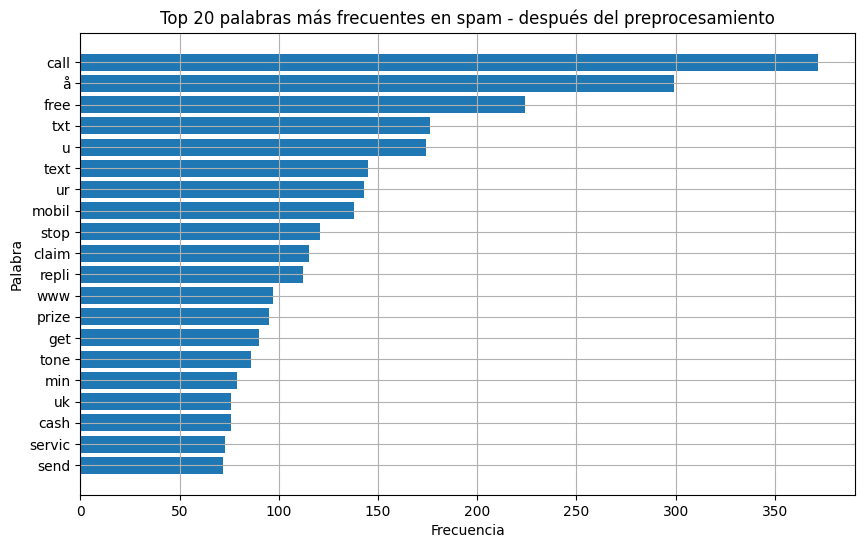

In [26]:
plot_top_words(top_spam_clean, "Top 20 palabras más frecuentes en spam - después del preprocesamiento")

### Top 20 palabras más frecuentes en ham después del preprocesamiento

In [27]:
top_ham_clean = get_top_words(df, "ham", "clean_tokens", top_n=20)
top_ham_clean

,word,frequency
0,u,958
1,go,410
2,get,341
3,call,288
4,come,288
5,ok,282
6,lt,239
7,know,237
8,like,236
9,love,236


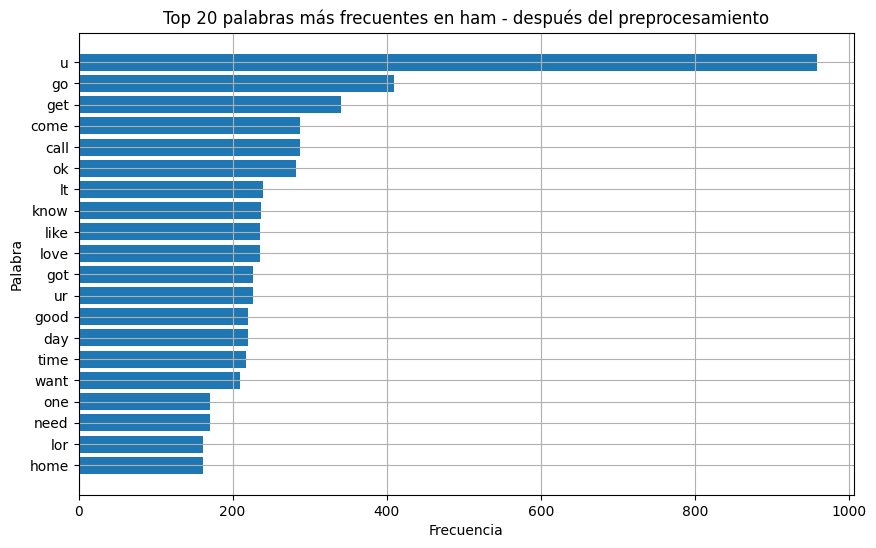

In [28]:
plot_top_words(top_ham_clean, "Top 20 palabras más frecuentes en ham - después del preprocesamiento")

### WordCloud para spam después del preprocesamiento

In [29]:
spam_clean_text = " ".join(df.loc[df["label"] == "spam", "clean_message"])
plot_wordcloud(spam_clean_text, "WordCloud spam - después del preprocesamiento")

WordCloud no disponible. Instala con: pip install wordcloud


### WordCloud para ham después del preprocesamiento

In [30]:
ham_clean_text = " ".join(df.loc[df["label"] == "ham", "clean_message"])
plot_wordcloud(ham_clean_text, "WordCloud ham - después del preprocesamiento")

WordCloud no disponible. Instala con: pip install wordcloud


## 5. Análisis comparativo de palabras frecuentes

A continuación se comparan las 20 palabras más frecuentes de cada clase después del preprocesamiento. Esta comparación ayuda a identificar vocabulario compartido y vocabulario más discriminativo.

In [31]:
spam_top_set = set(top_spam_clean["word"])
ham_top_set = set(top_ham_clean["word"])

common_words = sorted(spam_top_set.intersection(ham_top_set))
spam_exclusive = sorted(spam_top_set.difference(ham_top_set))
ham_exclusive = sorted(ham_top_set.difference(spam_top_set))

print("Palabras comunes en el top 20 de spam y ham:")
print(common_words)

print("\nPalabras exclusivas del top 20 de spam:")
print(spam_exclusive)

print("\nPalabras exclusivas del top 20 de ham:")
print(ham_exclusive)

Palabras comunes en el top 20 de spam y ham:
['call', 'get', 'u', 'ur']

Palabras exclusivas del top 20 de spam:
['cash', 'claim', 'free', 'min', 'mobil', 'prize', 'repli', 'send', 'servic', 'stop', 'text', 'tone', 'txt', 'uk', 'www', 'å']

Palabras exclusivas del top 20 de ham:
['come', 'day', 'go', 'good', 'got', 'home', 'know', 'like', 'lor', 'love', 'lt', 'need', 'ok', 'one', 'time', 'want']


## 6. Reflexión y análisis final

### 6.1 ¿Qué cambios son más notorios entre los indicadores antes y después del preprocesamiento?

Los cambios más notorios aparecen en las frecuencias de palabras y en la longitud de los mensajes. Antes del preprocesamiento, las palabras más frecuentes están dominadas por términos funcionales como `to`, `a`, `you`, `the`, `and`, entre otras. Estas palabras aparecen mucho, pero no necesariamente ayudan a distinguir spam de ham.

Después del preprocesamiento, el vocabulario se vuelve más informativo. En spam aparecen con mayor claridad términos asociados a promociones, instrucciones o recompensas, como raíces relacionadas con `free`, `txt`, `text`, `mobil`, `stop`, `claim`, `prize`, `cash` y `won`.

En ham, en cambio, aparecen palabras más conversacionales, como raíces relacionadas con `come`, `ok`, `know`, `like`, `love`, `good`, `day`, `time`, `want`, `need` y `go`.

También se reduce la longitud promedio de los mensajes porque se eliminan stopwords, puntuación y tokens poco informativos. Sin embargo, se conserva una diferencia importante: los mensajes spam tienden a ser más largos que los ham.

### 6.2 ¿Hay palabras en común entre spam y ham?

Sí. En el análisis realizado, algunas palabras aparecen en ambos grupos, por ejemplo términos abreviados o conversacionales como `u`, `ur`, `just`, `s` y `t`. Estas palabras son comunes porque el dataset proviene de SMS, donde abundan abreviaciones y escritura informal.

Estas palabras compartidas no son necesariamente buenas por sí solas para clasificar, porque aparecen en ambas clases.

### 6.3 ¿Qué palabras son exclusivas de cada clase?

En spam aparecen palabras exclusivas del top 20 asociadas a promociones o acciones comerciales, como:

- `free`
- `txt`
- `text`
- `mobil`
- `stop`
- `claim`
- `prize`
- `cash`
- `won`
- `www`

En ham aparecen palabras exclusivas más relacionadas con conversación cotidiana, como:

- `come`
- `ok`
- `know`
- `like`
- `love`
- `good`
- `day`
- `time`
- `want`
- `need`
- `go`

### 6.4 ¿Qué patrones se deducen de estas diferencias?

Los mensajes spam parecen tener un lenguaje más persuasivo, promocional y orientado a una acción. Usan palabras como `free`, `claim`, `prize`, `won` o `cash`, que sugieren premios, ofertas o beneficios. También aparecen términos relacionados con canales de respuesta, como `txt`, `text`, `stop`, `www` y `mobil`.

Los mensajes ham reflejan comunicación personal. Incluyen palabras de coordinación, emociones o actividades diarias, como `come`, `ok`, `love`, `good`, `day` y `time`.

### 6.5 ¿Qué características del texto podrían ser útiles para distinguir spam y ham?

A partir del análisis exploratorio, las siguientes características podrían ser útiles para un clasificador:

1. **Longitud del mensaje:** los mensajes spam tienden a ser más largos.
2. **Presencia de palabras promocionales:** `free`, `prize`, `claim`, `cash`, `won`.
3. **Presencia de instrucciones de acción:** `call`, `txt`, `text`, `reply`, `stop`.
4. **Presencia de enlaces o términos web:** por ejemplo `www`.
5. **Presencia de números o códigos:** muchos mensajes spam incluyen teléfonos, códigos de reclamo o montos.
6. **Frecuencia de signos de exclamación o mayúsculas:** aunque no se modeló directamente aquí, visualmente el spam suele tener más énfasis.
7. **Cantidad de tokens después del preprocesamiento:** aun limpio, el spam conserva más contenido informativo promedio.

En conclusión, el preprocesamiento permite reducir ruido y hacer más visibles las diferencias entre ambas clases. Esto prepara el dataset para una siguiente fase de modelado, donde se podrían usar representaciones como Bag of Words, TF-IDF o embeddings para entrenar un clasificador.

## 7. Posible siguiente paso: preparación para modelado

Aunque este laboratorio se enfoca en EDA y preprocesamiento, el siguiente paso natural sería convertir el texto en variables numéricas usando técnicas como:

- Bag of Words;
- TF-IDF;
- n-gramas;
- embeddings.

Después se podría entrenar un clasificador como Naive Bayes, Logistic Regression, Random Forest o modelos más avanzados.